In [1]:
import osmnx as ox
import geopandas as gpd
print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
import osmnx as ox

# Descargar las carreteras de la Comunidad de Madrid
print("Descargando datos de Madrid... esto puede tardar unos minutos")
vias = ox.graph_from_place("Comunidad de Madrid, Spain", network_type="drive")
print("Datos descargados correctamente")

Descargando datos de Madrid... esto puede tardar unos minutos
Datos descargados correctamente


In [3]:
# Convertir los datos a un formato que podamos trabajar
vias_gdf = ox.graph_to_gdfs(vias, nodes=False, edges=True)

# Ver cuántos tramos tenemos y qué columnas hay
print(f"Total de tramos: {len(vias_gdf)}")
print(f"Columnas disponibles: {list(vias_gdf.columns)}")

Total de tramos: 271072
Columnas disponibles: ['osmid', 'highway', 'lanes', 'maxspeed', 'name', 'oneway', 'ref', 'reversed', 'length', 'geometry', 'bridge', 'junction', 'tunnel', 'access', 'width', 'est_width']


In [4]:
# Ver cuántos tramos tienen maxspeed y cuántos no
con_velocidad = vias_gdf[vias_gdf["maxspeed"].notna()]
sin_velocidad = vias_gdf[vias_gdf["maxspeed"].isna()]

print(f"Tramos CON velocidad: {len(con_velocidad)}")
print(f"Tramos SIN velocidad: {len(sin_velocidad)}")
print(f"Porcentaje sin velocidad: {round(len(sin_velocidad)/len(vias_gdf)*100, 1)}%")

Tramos CON velocidad: 68198
Tramos SIN velocidad: 202874
Porcentaje sin velocidad: 74.8%


In [5]:
# Tabla de velocidades por tipo de vía
velocidades = {
    "motorway": 120, "motorway_link": 80,
    "trunk": 100, "trunk_link": 60,
    "primary": 90, "primary_link": 70,
    "secondary": 90, "secondary_link": 70,
    "tertiary": 50, "tertiary_link": 50,
    "unclassified": 50,
    "residential": 30,
    "living_street": 20,
    "service": 20,
    "track": 20
}

# Aplicar velocidad inferida donde no hay maxspeed
def inferir_velocidad(row):
    if row["maxspeed"] is not None and row["maxspeed"] == row["maxspeed"]:
        return row["maxspeed"]  # ya tiene velocidad, se va a respetar
    highway = row["highway"]
    if isinstance(highway, list):
        highway = highway[0]  # a veces viene como lista
    return velocidades.get(highway, 50)  # Se pondra 50 por defecto si no se conoce

vias_gdf["maxspeed_inferida"] = vias_gdf.apply(inferir_velocidad, axis=1)
print("Velocidades inferidas correctamente")
print(vias_gdf[["highway", "maxspeed", "maxspeed_inferida"]].head(10))

Velocidades inferidas correctamente
                                           highway    maxspeed  \
u        v          key                                          
21741584 21741587   0                     motorway         100   
21741587 759985345  0                motorway_link    [40, 70]   
         310025091  0                     motorway         100   
21741595 1317348460 0    [motorway_link, tertiary]          40   
         310031145  0                     motorway  [120, 100]   
26387798 310030930  0                     motorway         120   
         2138901502 0                motorway_link          70   
26388046 305294808  0                motorway_link    [40, 60]   
         305295292  0                     motorway         100   
26388231 313011964  0                     motorway         100   

                        maxspeed_inferida  
u        v          key                    
21741584 21741587   0                 100  
21741587 759985345  0            [40, 7

In [6]:
# Guardar como GeoJSON
vias_gdf["maxspeed_inferida"] = vias_gdf["maxspeed_inferida"].astype(str)
vias_gdf.to_file("velocidades_madrid.geojson", driver="GeoJSON")
print("Archivo guardado correctamente como velocidades_madrid.geojson")

Archivo guardado correctamente como velocidades_madrid.geojson


In [8]:
# Descargar polígonos de landuse de Madrid
print("Descargando polígonos de landuse... puede tardar unos minutos")
landuse = ox.features_from_place(
    "Comunidad de Madrid, Spain",
    tags={"landuse": True}
)
print(f"Polígonos descargados: {len(landuse)}")
print(f"Tipos de landuse encontrados: {landuse['landuse'].unique()}")

Descargando polígonos de landuse... puede tardar unos minutos
Polígonos descargados: 34707
Tipos de landuse encontrados: <StringArray>
[               'military',              'industrial',
                  'quarry',                  'forest',
             'residential',                  'apiary',
       'recreation_ground',              'brownfield',
                  'retail',               'education',
           'village_green',                'cemetery',
              'greenfield',                  'meadow',
               'religious',                   'grass',
           'winter_sports',                'farmyard',
                'farmland',              'commercial',
                 'orchard',                 'railway',
                   'basin',               'flowerbed',
              'allotments',            'construction',
              'government',            'governmental',
                'landfill',              'healthcare',
                   'depot',             

In [9]:
# Definir zonas urbanas y rurales
zonas_urbanas = ["residential", "commercial", "industrial", "retail", 
                 "education", "healthcare", "construction", "garages"]

# Filtrar solo los polígonos urbanos y quedarnos solo con polígonos (no puntos)
landuse_urbano = landuse[
    (landuse["landuse"].isin(zonas_urbanas)) & 
    (landuse.geometry.geom_type.isin(["Polygon", "MultiPolygon"]))
].copy()

print(f"Polígonos urbanos: {len(landuse_urbano)}")

# Asegurarse de que ambas capas tienen el mismo sistema de coordenadas
landuse_urbano = landuse_urbano.to_crs(vias_gdf.crs)

# Hacer el spatial join
vias_con_contexto = gpd.sjoin(
    vias_gdf, 
    landuse_urbano[["landuse", "geometry"]], 
    how="left", 
    predicate="intersects"
)

# Marcar si cada tramo está en zona urbana o no
vias_con_contexto["es_urbano"] = vias_con_contexto["landuse"].notna()

print(f"Tramos en zona urbana: {vias_con_contexto['es_urbano'].sum()}")
print(f"Tramos en zona rural: {(~vias_con_contexto['es_urbano']).sum()}")

Polígonos urbanos: 13133
Tramos en zona urbana: 239400
Tramos en zona rural: 54020


In [10]:
# Velocidades según contexto urbano o interurbano
def velocidad_urbana(highway):
    if isinstance(highway, list):
        highway = highway[0]
    velocidades = {
        "motorway": 120, "motorway_link": 80,
        "trunk": 80, "trunk_link": 50,
        "primary": 50, "primary_link": 50,
        "secondary": 50, "secondary_link": 50,
        "tertiary": 30, "tertiary_link": 30,
        "unclassified": 30,
        "residential": 30,
        "living_street": 20,
        "service": 20,
        "track": 20
    }
    return velocidades.get(highway, 30)

def velocidad_interurbana(highway):
    if isinstance(highway, list):
        highway = highway[0]
    velocidades = {
        "motorway": 120, "motorway_link": 80,
        "trunk": 100, "trunk_link": 60,
        "primary": 90, "primary_link": 70,
        "secondary": 90, "secondary_link": 70,
        "tertiary": 70, "tertiary_link": 50,
        "unclassified": 50,
        "residential": 30,
        "living_street": 20,
        "service": 20,
        "track": 20
    }
    return velocidades.get(highway, 50)

# Aplicar velocidad según contexto
def inferir_con_contexto(row):
    # Si ya tiene maxspeed, respetarlo
    if row["maxspeed"] is not None and row["maxspeed"] == row["maxspeed"]:
        return row["maxspeed"]
    # Si no tiene, inferir según contexto
    if row["es_urbano"]:
        return velocidad_urbana(row["highway"])
    else:
        return velocidad_interurbana(row["highway"])

vias_con_contexto["maxspeed_final"] = vias_con_contexto.apply(inferir_con_contexto, axis=1)
print("Velocidades aplicadas correctamente")
print(vias_con_contexto[["highway", "es_urbano", "maxspeed", "maxspeed_final"]].head(10))

Velocidades aplicadas correctamente
                                           highway  es_urbano    maxspeed  \
u        v          key                                                     
21741584 21741587   0                     motorway      False         100   
21741587 759985345  0                motorway_link      False    [40, 70]   
         310025091  0                     motorway      False         100   
21741595 1317348460 0    [motorway_link, tertiary]       True          40   
         310031145  0                     motorway      False  [120, 100]   
26387798 310030930  0                     motorway      False         120   
         2138901502 0                motorway_link      False          70   
26388046 305294808  0                motorway_link      False    [40, 60]   
         305295292  0                     motorway      False         100   
26388231 313011964  0                     motorway      False         100   

                        maxspeed_final 

In [11]:
# Guardar resultado final
vias_con_contexto["maxspeed_final"] = vias_con_contexto["maxspeed_final"].astype(str)

# Quedarnos solo con las columnas importantes
resultado = vias_con_contexto[["highway", "maxspeed", "es_urbano", "maxspeed_final", "geometry"]].copy()

# Eliminar duplicados que puede haber generado el spatial join
resultado = resultado[~resultado.index.duplicated(keep="first")]

resultado.to_file("velocidades_madrid_final.geojson", driver="GeoJSON")

print(f"Archivo guardado: velocidades_madrid_final.geojson")
print(f"Total tramos: {len(resultado)}")
print(f"Tramos con velocidad original OSM: {resultado['maxspeed'].notna().sum()}")
print(f"Tramos con velocidad inferida: {resultado['maxspeed'].isna().sum()}")

Archivo guardado: velocidades_madrid_final.geojson
Total tramos: 271072
Tramos con velocidad original OSM: 68198
Tramos con velocidad inferida: 202874


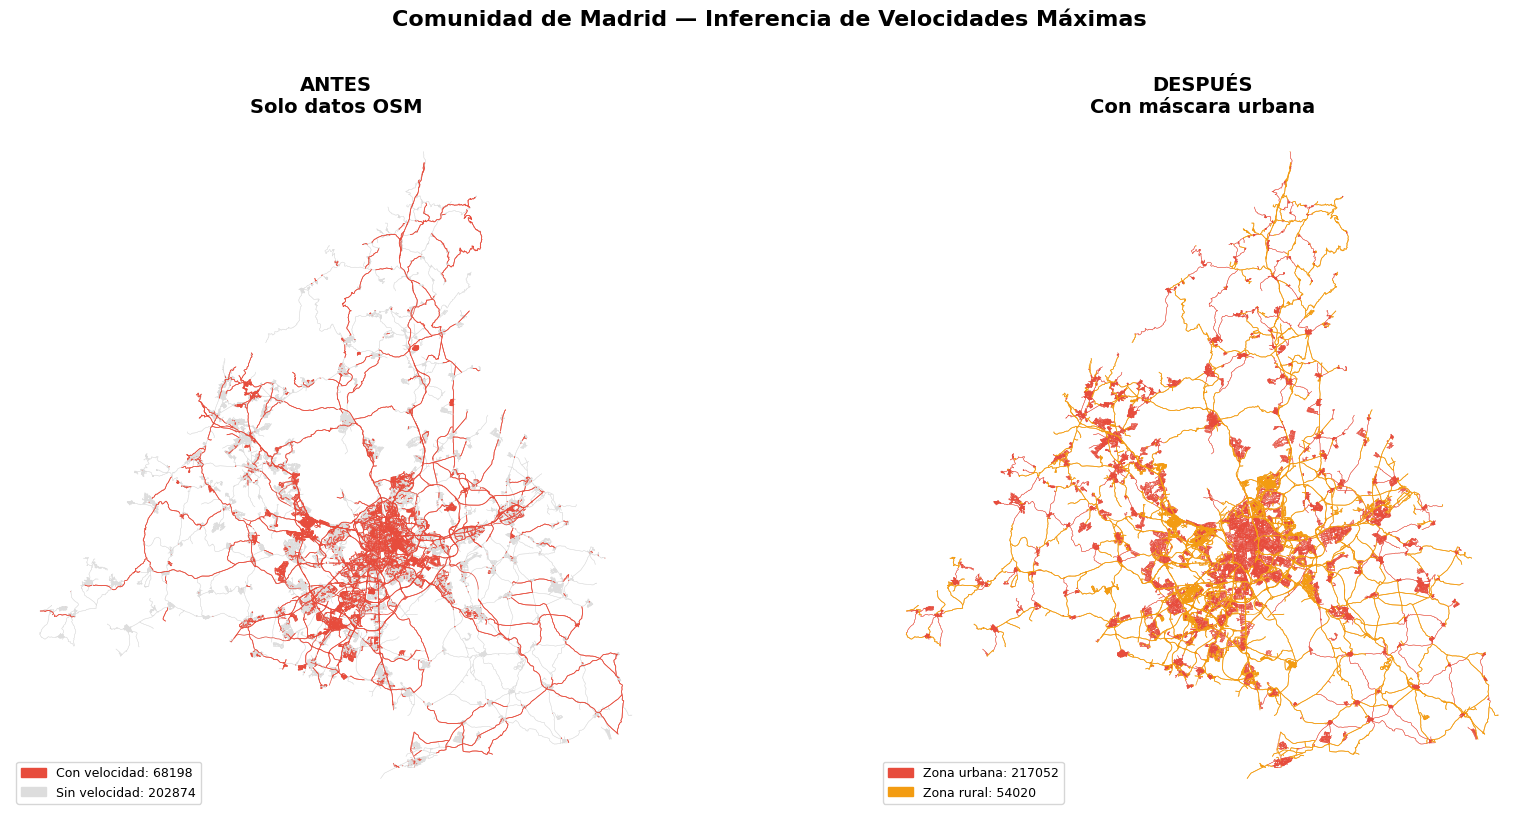

Mapa guardado como comparacion_antes_despues.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# MAPA 1 - Antes (solo datos OSM)
ax1.set_facecolor("#f0f0f0")
vias_gdf[vias_gdf["maxspeed"].isna()].plot(ax=ax1, color="#dddddd", linewidth=0.3)
vias_gdf[vias_gdf["maxspeed"].notna()].plot(ax=ax1, color="#e74c3c", linewidth=0.5)
ax1.set_title("ANTES\nSolo datos OSM", fontsize=14, fontweight="bold")
ax1.axis("off")
parche1 = mpatches.Patch(color="#e74c3c", label=f"Con velocidad: {len(con_velocidad)}")
parche2 = mpatches.Patch(color="#dddddd", label=f"Sin velocidad: {len(sin_velocidad)}")
ax1.legend(handles=[parche1, parche2], loc="lower left", fontsize=9)

# MAPA 2 - Después (con máscara urbana)
ax2.set_facecolor("#f0f0f0")
resultado[resultado["es_urbano"] == True].plot(ax=ax2, color="#e74c3c", linewidth=0.3)
resultado[resultado["es_urbano"] == False].plot(ax=ax2, color="#f39c12", linewidth=0.5)
ax2.set_title("DESPUÉS\nCon máscara urbana", fontsize=14, fontweight="bold")
ax2.axis("off")
parche3 = mpatches.Patch(color="#e74c3c", label=f"Zona urbana: {(resultado['es_urbano']==True).sum()}")
parche4 = mpatches.Patch(color="#f39c12", label=f"Zona rural: {(resultado['es_urbano']==False).sum()}")
ax2.legend(handles=[parche3, parche4], loc="lower left", fontsize=9)

plt.suptitle("Comunidad de Madrid — Inferencia de Velocidades Máximas", 
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("comparacion_antes_despues.png", dpi=150, bbox_inches="tight")
plt.show()
print("Mapa guardado como comparacion_antes_despues.png")